In [12]:
import numpy as np
import pandas as pd
import yfinance as yf
import json
import datetime
import os
import time
import pytz
import matplotlib.pyplot as plt
import scipy
from arch import arch_model

In [89]:
symbol='LLY'

In [90]:
eastern = pytz.timezone('US/Eastern')
stockprices = pd.read_csv(f'StockPriceData/{symbol}.csv')
stockprices['Date'] = pd.to_datetime(stockprices['Date'], utc=True)
stockprices['Date'] = stockprices['Date'].dt.tz_convert('US/Eastern')
stockprices['close_prev'] = stockprices['Close'].shift(1)
stockprices['log_ret'] = np.log(stockprices['Close']/stockprices['close_prev'])
stockprices = stockprices[(stockprices['Date']>eastern.localize(datetime.datetime(2023,5,20, 0,0,0))) & (stockprices['Date']<eastern.localize(datetime.datetime(2024,5,20, 0,0,0)))]
stockprices

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,close_prev,log_ret
12853,2023-05-22 00:00:00-04:00,438.018072,448.507412,426.266890,427.844208,4398000,0.0,0.0,436.115356,-0.019148
12854,2023-05-23 00:00:00-04:00,426.789375,429.717318,415.540950,417.216858,4492100,0.0,0.0,427.844208,-0.025153
12855,2023-05-24 00:00:00-04:00,417.995737,422.885490,414.308709,419.740662,3133000,0.0,0.0,417.216858,0.006031
12856,2023-05-25 00:00:00-04:00,420.341966,422.136200,413.855130,421.258789,2882200,0.0,0.0,419.740662,0.003610
12857,2023-05-26 00:00:00-04:00,418.882904,425.557052,417.670341,419.760315,2338400,0.0,0.0,421.258789,-0.003563
...,...,...,...,...,...,...,...,...,...,...
13098,2024-05-13 00:00:00-04:00,757.019742,757.069305,744.159855,751.268982,1848900,0.0,0.0,753.549438,-0.003031
13099,2024-05-14 00:00:00-04:00,745.141400,758.011211,745.141400,757.495605,1956200,0.0,0.0,751.268982,0.008254
13100,2024-05-15 00:00:00-04:00,758.955691,782.305831,757.912780,781.670227,3038300,1.3,0.0,757.495605,0.031415
13101,2024-05-16 00:00:00-04:00,779.375882,781.133809,764.904916,765.878235,2299700,0.0,0.0,781.670227,-0.020410


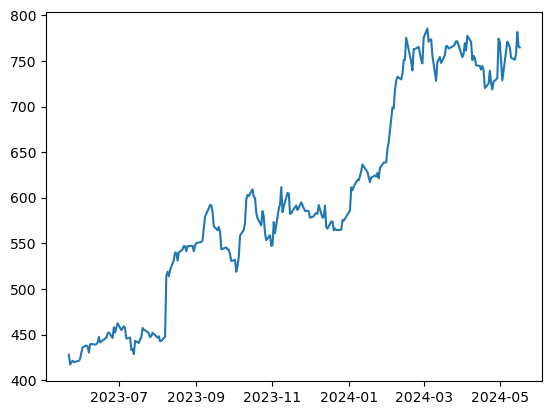

In [91]:
plt.plot(stockprices['Date'], stockprices['Close'])
plt.show()

In [92]:
model = arch_model(100*stockprices['log_ret'], vol='Garch', p=1, q=1)
res = model.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 906.9952677321054
Iteration:      2,   Func. Count:     13,   Neg. LLF: 515.8221947164303
Iteration:      3,   Func. Count:     20,   Neg. LLF: 509.82062604949124
Iteration:      4,   Func. Count:     25,   Neg. LLF: 509.8189151538341
Iteration:      5,   Func. Count:     30,   Neg. LLF: 509.81065952009175
Iteration:      6,   Func. Count:     35,   Neg. LLF: 509.8001645951047
Iteration:      7,   Func. Count:     40,   Neg. LLF: 509.79026511160896
Iteration:      8,   Func. Count:     45,   Neg. LLF: 509.76174716139064
Iteration:      9,   Func. Count:     50,   Neg. LLF: 509.75937647150107
Iteration:     10,   Func. Count:     55,   Neg. LLF: 509.7570915107941
Iteration:     11,   Func. Count:     60,   Neg. LLF: 509.7568160053778
Iteration:     12,   Func. Count:     65,   Neg. LLF: 509.75678997763805
Iteration:     13,   Func. Count:     69,   Neg. LLF: 509.75678997852214
Optimization terminated successfully    (Exit mode 0)
   

In [93]:
horizon = 252             # Forecast horizon (e.g., 10 steps)

simulation = model.simulate(res.params, nobs=horizon)
simulation
#simulation['data'].to_numpy()/100

,data,volatility,errors
0,1.015641,1.859063,0.790907
1,2.267913,1.859063,2.043179
2,-1.353270,1.859063,-1.578004
3,-0.784204,1.859063,-1.008938
4,-0.920033,1.859063,-1.144768
...,...,...,...
247,1.454429,1.859063,1.229694
248,-1.468351,1.859063,-1.693085
249,0.902213,1.859063,0.677479
250,-0.579104,1.859063,-0.803838


In [94]:
res.summary

<bound method ARCHModelResult.summary of                      Constant Mean - GARCH Model Results                      
Dep. Variable:                log_ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -509.757
Distribution:                  Normal   AIC:                           1027.51
Method:            Maximum Likelihood   BIC:                           1041.60
                                        No. Observations:                  250
Date:                Thu, Jun 26 2025   Df Residuals:                      249
Time:                        12:12:15   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.224

In [95]:
res.params.mu

0.22473417547870617

In [96]:
def stock_path_garch_sigma(S0, r, n_paths, n_steps):
    '''
    Generation of custom stock paths following Geometeric Brownian motion,
    but log-returns do not have constant volatility.
    
    Each step of the log-returns, there is a 
    1) 50% the volatility is .2
    2) 30% chance the volatility is .3
    3) 20% chance the volatility is .45
    
    Inputs:
    S0 (float): initial stock value
    t (float): time interval of stock path movements in years
    r (float): risk-free interest rate
    mu (float): drift of log-returns
    n_paths (int): number of stock paths
    n_steps (float): number of steps in each stock path
    
    Returns:
    
    Simuatled stock paths
    '''
    
    #Noise in volatility
    noise = np.random.normal(0,1,size = (n_paths, n_steps))
    
    #Custom sigma that is not constant

    sigma = np.zeros((n_paths, n_steps))

    for i in range(n_paths):
        simulation = model.simulate(res.params, nobs=n_steps)
        sigma[i] = simulation['errors'].to_numpy()/100
        
    #Time increment between each step
    dt = 1
    
    #log-returns between each step
    increments = (r)*(1/252) + sigma - .5*sigma**2
    increments = (res.params.mu/100 + r*(1/252) - .5*sigma**2) + sigma*np.sqrt(dt)*noise
    
    #Cumulative log-returns at each step
    log_returns = np.cumsum(increments, axis = 1)
    
    
    #paths
    paths = S0*np.exp(log_returns)
    
    
    #Adjoint initial value S0 at start of each simulated path
    paths = np.insert(paths, 0, S0, axis = 1)
    
    
    return paths
    
    

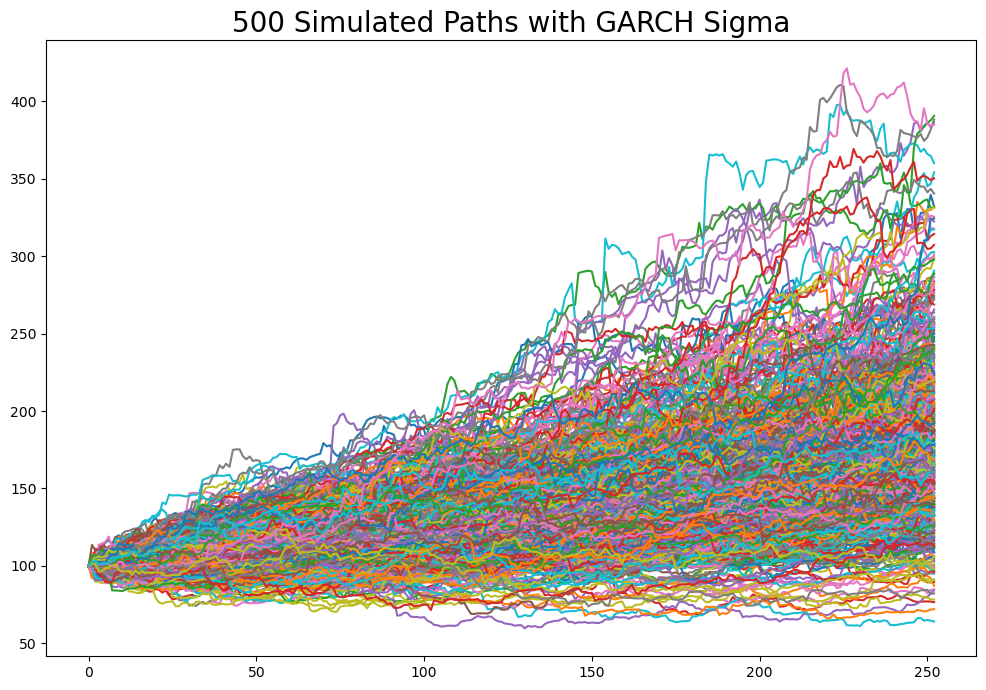

In [97]:
#5 Simulated paths of daily steps over 1-year period and plot

S0 = 100
t = 1
r = 0.039
mu = 0.275
n_paths = 500
n_steps = 252


simulated_paths = stock_path_garch_sigma(S0, r, n_paths, n_steps)


plt.figure(figsize = (12,8))

for path in simulated_paths:
    plt.plot(path)
    
plt.title(f'{n_paths} Simulated Paths with GARCH Sigma', size = 20)


plt.show()

In [ ]:
#Create function that does monte-carlo simulation of call option price with volatility modeled using GARCH process

def monte_sim_call_garch(S0, K, r, n_paths, n_steps):
    """
    Monte Carlo simulation to estimate the price of a European call option 
    under the Black-Scholes model.

    Parameters:
        S0 (float): Initial stock price
        K (float): Strike price
        sigma (float): Volatility of the stock
        t (float): Time to maturity (in years)
        r (float): Risk-free interest rate
        N (int): Number of simulated paths

    Returns:
        float: Estimated call option price
    """

   #Noise in volatility
    noise = np.random.normal(0,1,size = (n_paths, n_steps))
    
    #Custom sigma that is not constant

    sigma = np.zeros((n_paths, n_steps))

    for i in range(n_paths):
        simulation = model.simulate(res.params, nobs=n_steps)
        sigma[i] = simulation['errors'].to_numpy()/100
        
    #Time increment between each step
    dt = 1
    
    #log-returns between each step
    increments = (res.params.mu/100 + r*(1/252) - .5*sigma**2) + sigma*np.sqrt(dt)*noise
    
    #Cumulative log-returns at each step
    log_returns = np.cumsum(increments, axis = 1)
    
    
    #paths
    paths = S0*np.exp(log_returns)

    end_points = paths[:,-1]
    
    call_payouts = np.maximum(end_points - K, 0)

    call_sim_value = np.exp(-r)*np.mean(call_payouts)

    return call_sim_value
    

In [113]:
S0 = 100
r = 0.039
n_paths = 5000
n_steps = 252
K=110

for i in range(5):
    print(monte_sim_call_garch(S0, K, r, n_paths, n_steps))

71.37141390693843
72.1101073891944
71.20212117068888
69.89789100904464
70.34695648035118


In [ ]:
monte_sim_call_garch(S0, K, r, n_paths, n_steps)

71.02361363873683

In [112]:
def monte_sim_call_delta(S0, K, t, r, n_paths):

    n_steps = t*252
    #simulate path endpoints

    bump = .01*S0 #epsilon in above estimation

    #Noise in volatility
    noise = np.random.normal(0,1,size = (n_paths, n_steps))
    
    #Custom sigma that is not constant

    sigma = np.zeros((n_paths, n_steps))

    for i in range(n_paths):
        simulation = model.simulate(res.params, nobs=n_steps)
        sigma[i] = simulation['errors'].to_numpy()/100
    
    #log-returns between each step
    increments = (res.params.mu/100 + r*(1/n_steps) - .5*sigma**2) + sigma*noise
    
    #Cumulative log-returns at each step
    log_returns = np.cumsum(increments, axis = 1)
    
    
    #paths
    paths_up = (S0+bump)*np.exp(log_returns)

    paths_down = (S0-bump)*np.exp(log_returns)

    calls_up = np.maximum(paths_up[:,-1] - K, 0)*np.exp(-r*t)

    calls_down = np.maximum(paths_down[:,-1] - K, 0)*np.exp(-r*t)

    delta_sims = (calls_up - calls_down)/(2*bump)

    return np.mean(delta_sims)



In [117]:
S0 = 100
r = 0.039
n_paths = 800
K=110
t=1

monte_sim_call_delta(S0, K, t, r, n_paths)

1.6769276675072604